# GENERADOR DE DATOS SINTÉTICOS: Clientes y Ventas

## Concepto
Este notebook implementa un generador de datos sintéticos que crea conjuntos de datos 
realistas para pruebas y análisis. Genera información de clientes, productos y ventas 
con relaciones lógicas entre los datos.

**Características:**
- Generación de datos coherentes y realistas
- Relaciones lógicas entre tablas (clientes → ventas → productos)
- Distribuciones estadísticas realistas (edades, montos, fechas)
- Múltiples formatos de exportación
- Datos anonimizados pero consistentes

**Formatos de salida:**
- **CSV** (Comma-Separated Values): Formato universal para hojas de cálculo
- **JSON** (JavaScript Object Notation): Formato para APIs y aplicaciones web
- **Excel** (.xlsx): Formato para análisis en Excel
- **SQL**: Scripts para bases de datos

**Aplicaciones:**
- Pruebas de software sin usar datos reales
- Desarrollo y testing de bases de datos
- Demostraciones y tutoriales
- Prototipado rápido de aplicaciones
- Entrenamiento de modelos de machine learning

In [1]:
# ============================================
# INSTALACIÓN Y VERIFICACIÓN DE LIBRERÍAS
# ============================================

import pandas as pd
import numpy as np
from faker import Faker
import random
from datetime import datetime, timedelta
import os
import matplotlib.pyplot as plt


# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## Librerías utilizadas

#### 1. **pandas** (Data manipulation)
- **Propósito**: Manipulación y análisis de datos estructurados
- **Uso**: Crear DataFrames, exportar a CSV/Excel, filtrar datos
- **Características**: Estructuras rápidas y flexibles (DataFrames)
- **Instalación**: `pip install pandas`

#### 2. **numpy** (Numerical computing)
- **Propósito**: Operaciones numéricas eficientes
- **Uso**: Generar distribuciones estadísticas, arrays multidimensionales
- **Ventaja**: Cálculos vectorizados muy rápidos
- **Instalación**: `pip install numpy`

#### 3. **Faker** (Generación de datos falsos realistas)
- **Propósito**: Crear datos ficticios realistas (nombres, direcciones, emails)
- **Uso**: Generar información de clientes creíble
- **Instalación**: `pip install Faker`

#### 4. **random** (estándar)
- **Propósito**: Generación de números aleatorios
- **Uso**: Selecciones aleatorias, probabilidades

#### 5. **datetime** (estándar)
- **Propósito**: Manejo de fechas y horas
- **Uso**: Generar fechas de registro, compras, etc.

#### 6. **matplotlib** (Visualización)
- **Propósito**: Visualizar estadísticas de los datos generados
- **Uso**: Verificar que los datos tengan distribuciones realistas (histogramas, diagramas de caja)
- **Instalación**: `pip install matplotlib seaborn`

#### 7. **openpyxl** (Excel)
- **Propósito**: Exportar a formato Excel
- **Uso**: Guardar datos en .xlsx para análisis en Excel
- **Instalación**: `pip install openpyxl`

In [2]:
# ============================================
# CLASE PRINCIPAL: GeneradorDatosSinteticos
# ============================================

class GeneradorDatosSinteticos:
    """
    Generador completo de datos sintéticos para clientes, productos y ventas
    """
    
    def __init__(self, idioma='es_ES', semilla=None):
        """
        Inicializa el generador con configuración regional
        
        Args:
            idioma (str): Código de idioma para Faker ('es_ES', 'en_US', etc.)
            semilla (int): Semilla para reproducibilidad (None = aleatorio)
        """
        # Configurar Faker para datos realistas en español
        self.faker = Faker(idioma)
        
        # Semilla para reproducibilidad
        if semilla:
            Faker.seed(semilla)
            random.seed(semilla)
            np.random.seed(semilla)
            print(f"Semilla establecida: {semilla} (resultados reproducibles)")
        
        # Categorías de productos
        self.categorias = {
            'Electrónica': ['Smartphone', 'Laptop', 'Tablet', 'Auriculares', 'Smartwatch'],
            'Hogar': ['Sofá', 'Mesa', 'Silla', 'Lámpara', 'Estantería'],
            'Ropa': ['Camiseta', 'Pantalón', 'Vestido', 'Chaqueta', 'Zapatos'],
            'Deportes': ['Bicicleta', 'Pesas', 'Esterilla', 'Balón', 'Raqueta'],
            'Libros': ['Novela', 'Ensayo', 'Manual', 'Cómic', 'Revista']
        }

        # Rangos de precios por categoría
        self.rangos_precios = {
            'Electrónica': (100, 1500),
            'Hogar': (50, 800),
            'Ropa': (20, 300),
            'Deportes': (30, 600),
            'Libros': (10, 100)
        }
        
        # Generar lista completa de productos
        self.productos = self._generar_catalogo_productos()
        
        print(f"Generador inicializado con {len(self.productos)} productos en catálogo")
    
    def _generar_catalogo_productos(self):
        """
        Genera un catálogo de productos con IDs únicos
        """
        productos = []
        id_producto = 1
        
        for categoria, items in self.categorias.items():
            for nombre in items:
                precio_min, precio_max = self.rangos_precios[categoria]
                producto = {
                    'id_producto': id_producto,
                    'nombre': nombre,
                    'categoria': categoria,
                    'precio_unitario': round(random.uniform(precio_min, precio_max), 2),
                    'stock': random.randint(10, 500),
                    'proveedor': self.faker.company()
                }
                productos.append(producto)
                id_producto += 1
        
        return productos
    
    def generar_clientes(self, n_clientes=100):
        """
        Genera una lista de clientes sintéticos
        
        Args:
            n_clientes (int): Número de clientes a generar
        
        Returns:
            pd.DataFrame: DataFrame con datos de clientes
        """
        print(f"\nGenerando {n_clientes} clientes...")
        clientes = []
        
        for i in range(1, n_clientes + 1):
            # Datos básicos
            nombre = self.faker.first_name()
            apellido = self.faker.last_name()
            
            # Generar email basado en el nombre
            email = f"{nombre.lower()}.{apellido.lower()}@{self.faker.free_email_domain()}"
            
            # Teléfono (formato español)
            telefono = self.faker.phone_number()
            
            # Edad con distribución realista (más gente entre 25-55)
            edad = int(np.random.normal(40, 15))
            edad = max(18, min(90, edad))  # Limitar entre 18 y 90
            
            # Dirección completa
            direccion = self.faker.street_address()
            ciudad = self.faker.city()
            provincia = self.faker.province() if hasattr(self.faker, 'province') else self.faker.state()
            codigo_postal = self.faker.postcode()
            
            # Fecha de registro (últimos 3 años)
            dias_atras = random.randint(0, 1095)  # 3 años
            fecha_registro = datetime.now() - timedelta(days=dias_atras)
            
            # Segmento de cliente
            if edad < 25:
                segmento = random.choices(['Joven', 'Estudiante'], weights=[0.7, 0.3])[0]
            elif edad < 40:
                segmento = random.choices(['Profesional', 'Familia'], weights=[0.6, 0.4])[0]
            elif edad < 60:
                segmento = random.choices(['Familia', 'Senior'], weights=[0.5, 0.5])[0]
            else:
                segmento = 'Senior'
            
            # Cliente VIP? (10% son VIP)
            es_vip = random.random() < 0.1
            
            cliente = {
                'id_cliente': i,
                'nombre_completo': f"{nombre} {apellido}",
                'email': email,
                'telefono': telefono,
                'edad': edad,
                'genero': random.choice(['M', 'F', 'Otro']),
                'direccion': direccion,
                'ciudad': ciudad,
                'provincia': provincia,
                'codigo_postal': codigo_postal,
                'fecha_registro': fecha_registro.strftime('%Y-%m-%d'),
                'segmento': segmento,
                'vip': es_vip,
                'activo': random.random() < 0.95  # 95% activos
            }
            
            clientes.append(cliente)
        
        # Crear DataFrame
        df_clientes = pd.DataFrame(clientes)
        print(f"{len(df_clientes)} clientes generados")
        
        return df_clientes
    
    def generar_ventas(self, df_clientes, n_ventas=500, fecha_inicio=None, fecha_fin=None):
        """
        Genera un registro de ventas asociadas a clientes y productos
        
        Args:
            df_clientes (pd.DataFrame): DataFrame con clientes
            n_ventas (int): Número de ventas a generar
            fecha_inicio (datetime): Fecha más antigua (None = hace 1 año)
            fecha_fin (datetime): Fecha más reciente (None = hoy)
        
        Returns:
            pd.DataFrame: DataFrame con ventas
        """
        print(f"\nGenerando {n_ventas} ventas...")
        
        # Configurar fechas
        if fecha_fin is None:
            fecha_fin = datetime.now()
        if fecha_inicio is None:
            fecha_inicio = fecha_fin - timedelta(days=365)
        
        ventas = []
        
        # Clientes activos para ventas
        clientes_activos = df_clientes[df_clientes['activo'] == True]['id_cliente'].tolist()
        
        for i in range(1, n_ventas + 1):
            # Seleccionar cliente aleatorio (con peso por segmento)
            cliente_id = random.choice(clientes_activos)
            
            # Seleccionar producto aleatorio
            producto = random.choice(self.productos)
            
            # Cantidad (1-5 items, con distribución sesgada a 1-2)
            cantidad = int(np.random.exponential(1.5)) + 1
            cantidad = min(cantidad, 5)
            
            # Calcular importe
            precio_unitario = producto['precio_unitario']
            importe_total = round(precio_unitario * cantidad, 2)
            
            # Fecha aleatoria dentro del rango
            dias_rango = (fecha_fin - fecha_inicio).days
            dias_aleatorios = random.randint(0, dias_rango)
            fecha_venta = fecha_inicio + timedelta(days=dias_aleatorios)
            
            # Método de pago
            metodo_pago = random.choices(
                ['Tarjeta', 'Efectivo', 'Transferencia', 'PayPal'],
                weights=[0.6, 0.2, 0.15, 0.05]
            )[0]
            
            # Estado de la venta
            estado = random.choices(
                ['Completada', 'Pendiente', 'Cancelada', 'Devuelta'],
                weights=[0.85, 0.08, 0.05, 0.02]
            )[0]
            
            venta = {
                'id_venta': i,
                'id_cliente': cliente_id,
                'id_producto': producto['id_producto'],
                'producto_nombre': producto['nombre'],
                'categoria': producto['categoria'],
                'cantidad': cantidad,
                'precio_unitario': precio_unitario,
                'importe_total': importe_total,
                'fecha_venta': fecha_venta.strftime('%Y-%m-%d'),
                'metodo_pago': metodo_pago,
                'estado': estado,
                'descuento_aplicado': random.random() < 0.1  # 10% con descuento
            }
            
            ventas.append(venta)
        
        # Ordenar por fecha
        df_ventas = pd.DataFrame(ventas)
        df_ventas = df_ventas.sort_values('fecha_venta').reset_index(drop=True)
        
        print(f"{len(df_ventas)} ventas generadas")
        print(f"   Período: {fecha_inicio.strftime('%Y-%m-%d')} a {fecha_fin.strftime('%Y-%m-%d')}")
        
        return df_ventas
    
    def get_catalogo_productos(self):
        """
        Devuelve el catálogo de productos como DataFrame
        """
        return pd.DataFrame(self.productos)

In [3]:
# ============================================
# FUNCIONES DE EXPORTACIÓN
# ============================================

def exportar_datos(df_clientes, df_ventas, df_productos, formato='todos', nombre_base='datos_sinteticos'):
    """
    Exporta los datos generados a diferentes formatos
    
    Args:
        df_clientes (pd.DataFrame): Datos de clientes
        df_ventas (pd.DataFrame): Datos de ventas
        df_productos (pd.DataFrame): Catálogo de productos
        formato (str): 'csv', 'excel', 'json', 'sql' o 'todos'
        nombre_base (str): Nombre base para los archivos
    """
    # Crear carpeta de salida
    carpeta_salida = f"datos_generados_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    os.makedirs(carpeta_salida, exist_ok=True)
    
    print(f"\nExportando datos a carpeta: {carpeta_salida}/")
    
    if formato in ['csv', 'todos']:
        # CSV
        df_clientes.to_csv(f"{carpeta_salida}/{nombre_base}_clientes.csv", index=False, encoding='utf-8')
        df_ventas.to_csv(f"{carpeta_salida}/{nombre_base}_ventas.csv", index=False, encoding='utf-8')
        df_productos.to_csv(f"{carpeta_salida}/{nombre_base}_productos.csv", index=False, encoding='utf-8')
        print("CSV exportados")
    
    if formato in ['excel', 'todos']:
        # Excel (múltiples hojas)
        with pd.ExcelWriter(f"{carpeta_salida}/{nombre_base}.xlsx", engine='openpyxl') as writer:
            df_clientes.to_excel(writer, sheet_name='Clientes', index=False)
            df_ventas.to_excel(writer, sheet_name='Ventas', index=False)
            df_productos.to_excel(writer, sheet_name='Productos', index=False)
        print("Excel exportado")
    
    if formato in ['json', 'todos']:
        # JSON
        df_clientes.to_json(f"{carpeta_salida}/{nombre_base}_clientes.json", orient='records', indent=2, force_ascii=False)
        df_ventas.to_json(f"{carpeta_salida}/{nombre_base}_ventas.json", orient='records', indent=2, force_ascii=False)
        df_productos.to_json(f"{carpeta_salida}/{nombre_base}_productos.json", orient='records', indent=2, force_ascii=False)
        print("JSON exportados")
    
    if formato in ['sql', 'todos']:
        # Script SQL
        with open(f"{carpeta_salida}/{nombre_base}_inserts.sql", 'w', encoding='utf-8') as f:
            # Crear tablas
            f.write("-- SCRIPT DE INSERCIÓN DE DATOS SINTÉTICOS\n\n")
            
            # Productos
            f.write("-- TABLA productos\n")
            for _, row in df_productos.iterrows():
                f.write(f"INSERT INTO productos VALUES ({row['id_producto']}, '{row['nombre']}', '{row['categoria']}', {row['precio_unitario']}, {row['stock']}, '{row['proveedor']}');\n")
            
            # Clientes
            f.write("\n-- TABLA clientes\n")
            for _, row in df_clientes.iterrows():
                f.write(f"INSERT INTO clientes VALUES ({row['id_cliente']}, '{row['nombre_completo']}', '{row['email']}', {row['edad']}, '{row['ciudad']}', '{row['fecha_registro']}', {row['vip']});\n")
            
            # Ventas
            f.write("\n-- TABLA ventas\n")
            for _, row in df_ventas.iterrows():
                f.write(f"INSERT INTO ventas VALUES ({row['id_venta']}, {row['id_cliente']}, {row['id_producto']}, {row['cantidad']}, {row['importe_total']}, '{row['fecha_venta']}', '{row['metodo_pago']}', '{row['estado']}');\n")
        
        print("Script SQL generado")
    
    print(f"\nTodos los archivos guardados en: {carpeta_salida}/")
    return carpeta_salida

In [4]:
# ============================================
# FUNCIONES DE VISUALIZACIÓN Y ANÁLISIS
# ============================================

def analizar_datos(df_clientes, df_ventas, df_productos):
    """
    Realiza un análisis básico de los datos generados
    """
    print("=" * 70)
    print("ANÁLISIS DE DATOS GENERADOS")
    print("=" * 70)
    
    # Estadísticas de clientes
    print("\nESTADÍSTICAS DE CLIENTES")
    print("-" * 40)
    print(f"Total clientes: {len(df_clientes)}")
    print(f"Edad media: {df_clientes['edad'].mean():.1f} años")
    print(f"Clientes VIP: {df_clientes['vip'].sum()} ({df_clientes['vip'].mean()*100:.1f}%)")
    print(f"Clientes activos: {df_clientes['activo'].sum()} ({df_clientes['activo'].mean()*100:.1f}%)")
    print("\nSegmentos:")
    print(df_clientes['segmento'].value_counts())
    
    # Estadísticas de ventas
    print("\nESTADÍSTICAS DE VENTAS")
    print("-" * 40)
    print(f"Total ventas: {len(df_ventas)}")
    print(f"Importe total: {df_ventas['importe_total'].sum():,.2f} €")
    print(f"Ticket medio: {df_ventas['importe_total'].mean():.2f} €")
    print(f"Venta máxima: {df_ventas['importe_total'].max():.2f} €")
    print("\nMétodos de pago:")
    print(df_ventas['metodo_pago'].value_counts())
    print("\nEstados de venta:")
    print(df_ventas['estado'].value_counts())
    
    # Productos
    print("\nESTADÍSTICAS DE PRODUCTOS")
    print("-" * 40)
    print(f"Total productos: {len(df_productos)}")
    print(f"Precio medio: {df_productos['precio_unitario'].mean():.2f} €")
    print("\nCategorías:")
    print(df_productos['categoria'].value_counts())

def visualizar_datos(df_clientes, df_ventas):
    """
    Crea visualizaciones de los datos generados
    Versión corregida para pandas >= 2.0
    """
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Distribución de edades
    ax1 = plt.subplot(2, 3, 1)
    df_clientes['edad'].hist(bins=20, edgecolor='black', alpha=0.7)
    ax1.set_title('Distribución de Edades')
    ax1.set_xlabel('Edad')
    ax1.set_ylabel('Frecuencia')
    
    # 2. Ventas por categoría
    ax2 = plt.subplot(2, 3, 2)
    ventas_cat = df_ventas.groupby('categoria')['importe_total'].sum().sort_values()
    ventas_cat.plot(kind='barh', ax=ax2)
    ax2.set_title('Ventas por Categoría')
    ax2.set_xlabel('Importe Total (€)')
    
    # 3. Evolución temporal de ventas (CORREGIDO)
    ax3 = plt.subplot(2, 3, 3)
    df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'])
    
    # CORRECCIÓN: Cambiar 'M' por 'ME' (Month End)
    ventas_por_mes = df_ventas.set_index('fecha_venta').resample('ME')['importe_total'].sum()
    
    ventas_por_mes.plot(ax=ax3, marker='o')
    ax3.set_title('Evolución Mensual de Ventas')
    ax3.set_xlabel('Fecha')
    ax3.set_ylabel('Ventas (€)')
    plt.xticks(rotation=45)
    
    # 4. Métodos de pago
    ax4 = plt.subplot(2, 3, 4)
    df_ventas['metodo_pago'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax4)
    ax4.set_title('Métodos de Pago')
    
    # 5. Distribución de tickets
    ax5 = plt.subplot(2, 3, 5)
    df_ventas['importe_total'].hist(bins=30, edgecolor='black', alpha=0.7)
    ax5.set_title('Distribución de Importes')
    ax5.set_xlabel('Importe (€)')
    ax5.set_ylabel('Frecuencia')
    
    # 6. Clientes por ciudad (top 10)
    ax6 = plt.subplot(2, 3, 6)
    df_clientes['ciudad'].value_counts().head(10).plot(kind='bar', ax=ax6)
    ax6.set_title('Top 10 Ciudades')
    ax6.set_xlabel('Ciudad')
    ax6.set_ylabel('Nº Clientes')
    plt.xticks(rotation=45)
    
    plt.suptitle('Visualización de Datos Sintéticos Generados', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [5]:
# ============================================
# GENERACIÓN PRINCIPAL DE DATOS
# ============================================

print("INICIANDO GENERACIÓN DE DATOS SINTÉTICOS")
print("=" * 70)

# Crear generador (con semilla fija para reproducibilidad)
generador = GeneradorDatosSinteticos(idioma='es_ES', semilla=42)

# 1. Generar catálogo de productos
df_productos = generador.get_catalogo_productos()
print(f"\nCatálogo de productos: {len(df_productos)} productos")
display(df_productos.head(10))

# 2. Generar clientes
df_clientes = generador.generar_clientes(n_clientes=200)
print(f"\nMuestra de clientes:")
display(df_clientes.head(10)[["nombre_completo","email","genero","edad"]])

# 3. Generar ventas
df_ventas = generador.generar_ventas(df_clientes, n_ventas=1000)
print(f"\nMuestra de ventas:")
display(df_ventas.head(10)[["cantidad",	"precio_unitario","importe_total"]])

INICIANDO GENERACIÓN DE DATOS SINTÉTICOS
Semilla establecida: 42 (resultados reproducibles)
Generador inicializado con 25 productos en catálogo

Catálogo de productos: 25 productos


,id_producto,nombre,categoria,precio_unitario,stock,proveedor
0,1,Smartphone,Electrónica,995.20,22,Banca Privada OLMJ S.L.N.E
1,2,Laptop,Electrónica,1138.17,135,Suministros BL S.Coop.
2,3,Tablet,Electrónica,412.50,387,Grupo Rivas S.A.T.
3,4,Auriculares,Electrónica,243.49,389,Alimentación Cuervo y asociados S.Com.
4,5,Smartwatch,Electrónica,1349.05,54,Fábrica Navarro S.A.
5,6,Sofá,Hogar,492.87,26,Caballero y Palomar S.L.L.
6,7,Mesa,Hogar,72.35,121,Banco Segovia & Asociados S.L.N.E
7,8,Silla,Hogar,224.50,318,Bermúdez y Marcos S.L.L.
8,9,Lámpara,Hogar,69.90,111,Fernandez & Asociados S.A.
9,10,Estantería,Hogar,587.01,369,Instalaciones Española S.L.L.



Generando 200 clientes...
200 clientes generados

Muestra de clientes:


,nombre_completo,email,genero,edad
0,Úrsula Parejo,úrsula.parejo@yahoo.com,M,47
1,Luna Font,luna.font@hotmail.com,M,37
2,Rosalina Murillo,rosalina.murillo@gmail.com,F,49
3,Rosario Balaguer,rosario.balaguer@hotmail.com,Otro,62
4,Clímaco Ayuso,clímaco.ayuso@hotmail.com,F,36
5,Lupe Torrecilla,lupe.torrecilla@gmail.com,M,36
6,Imelda Gutierrez,imelda.gutierrez@yahoo.com,F,63
7,Álvaro Cabo,álvaro.cabo@gmail.com,Otro,51
8,Gracia Calleja,gracia.calleja@gmail.com,F,32
9,Arsenio Acevedo,arsenio.acevedo@yahoo.com,F,48



Generando 1000 ventas...
1000 ventas generadas
   Período: 2025-02-24 a 2026-02-24

Muestra de ventas:


,cantidad,precio_unitario,importe_total
0,1,172.58,172.58
1,2,226.05,452.10
2,1,224.50,224.50
3,3,1138.17,3414.51
4,1,88.26,88.26
5,2,85.13,170.26
6,2,145.78,291.56
7,1,17.09,17.09
8,1,84.65,84.65
9,1,243.49,243.49


ANÁLISIS DE DATOS GENERADOS

ESTADÍSTICAS DE CLIENTES
----------------------------------------
Total clientes: 200
Edad media: 39.2 años
Clientes VIP: 17 (8.5%)
Clientes activos: 188 (94.0%)

Segmentos:
segmento
Senior         62
Familia        62
Profesional    44
Joven          23
Estudiante      9
Name: count, dtype: int64

ESTADÍSTICAS DE VENTAS
----------------------------------------
Total ventas: 1000
Importe total: 661,098.61 €
Ticket medio: 661.10 €
Venta máxima: 6745.25 €

Métodos de pago:
metodo_pago
Tarjeta          583
Efectivo         221
Transferencia    142
PayPal            54
Name: count, dtype: int64

Estados de venta:
estado
Completada    840
Pendiente      83
Cancelada      52
Devuelta       25
Name: count, dtype: int64

ESTADÍSTICAS DE PRODUCTOS
----------------------------------------
Total productos: 25
Precio medio: 323.79 €

Categorías:
categoria
Electrónica    5
Hogar          5
Ropa           5
Deportes       5
Libros         5
Name: count, dtype: int64


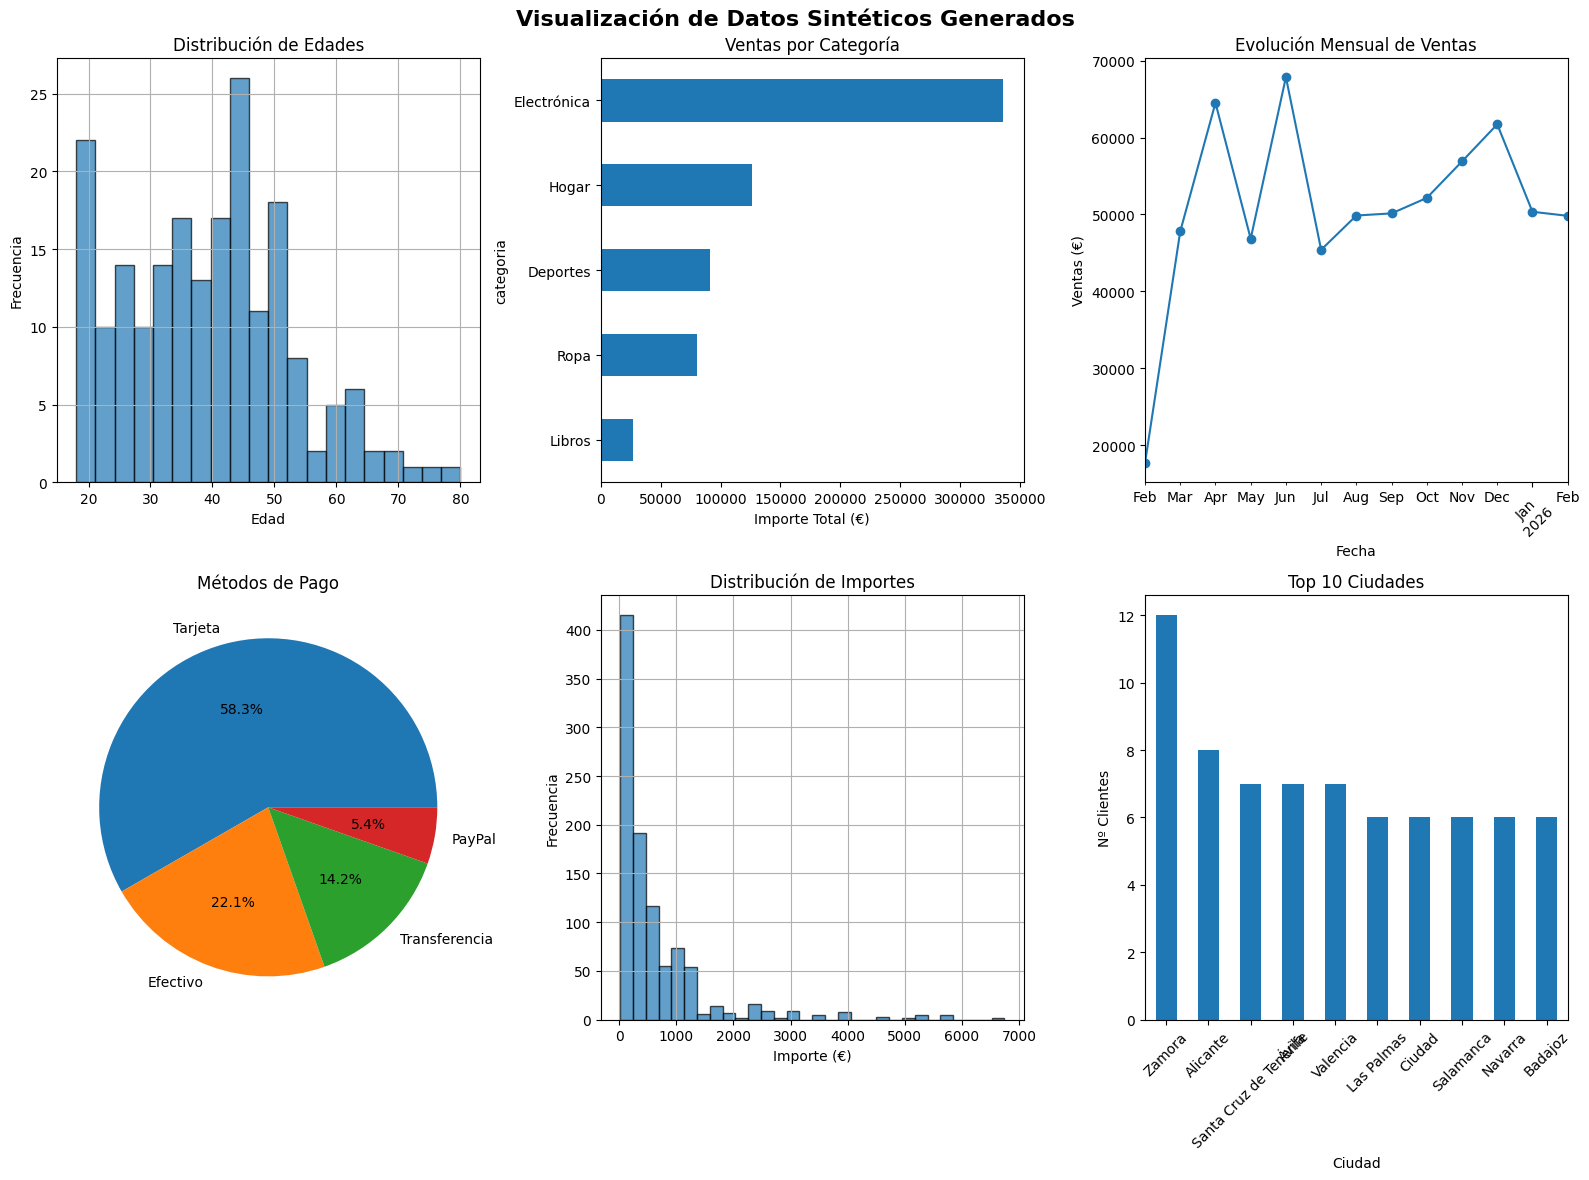


TOP 10 CLIENTES POR VOLUMEN DE COMPRA
--------------------------------------------------


,gasto_total,num_compras,nombre_completo,segmento,vip
id_cliente,,,,,
168,16904.97,5,Olalla Falcó,Senior,False
42,14279.03,10,Ángel Jara,Familia,False
194,11964.98,10,Calisto Goñi,Estudiante,False
147,11452.24,9,Encarna Hoyos,Estudiante,False
21,11169.03,6,Gloria Amores,Senior,False
172,10212.41,10,Mateo Castelló,Profesional,False
107,9527.61,5,María Cristina Agudo,Senior,False
94,9024.56,6,Guadalupe Echevarría,Profesional,False
73,8677.76,8,Jesusa Valencia,Familia,False



TOP 10 PRODUCTOS MÁS VENDIDOS
--------------------------------------------------


,,,cantidad,importe_total
id_producto,producto_nombre,categoria,,
18,Esterilla,Deportes,110,9708.60
16,Bicicleta,Deportes,102,19215.78
10,Estantería,Hogar,99,58113.99
2,Laptop,Electrónica,96,109264.32
15,Zapatos,Ropa,91,19608.68
13,Vestido,Ropa,90,22197.60
19,Balón,Deportes,88,7491.44
20,Raqueta,Deportes,88,19892.40
12,Pantalón,Ropa,87,12682.86


In [6]:
# ============================================
# ANÁLISIS Y VISUALIZACIÓN
# ============================================

# Análisis estadístico
analizar_datos(df_clientes, df_ventas, df_productos)

# Visualizaciones
visualizar_datos(df_clientes, df_ventas)

# Análisis adicional: Top clientes
print("\nTOP 10 CLIENTES POR VOLUMEN DE COMPRA")
print("-" * 50)
top_clientes = df_ventas.groupby('id_cliente').agg({
    'importe_total': 'sum',
    'id_venta': 'count'
}).rename(columns={'importe_total': 'gasto_total', 'id_venta': 'num_compras'})
top_clientes = top_clientes.join(df_clientes.set_index('id_cliente')[['nombre_completo', 'segmento', 'vip']])
top_clientes = top_clientes.sort_values('gasto_total', ascending=False).head(10)
display(top_clientes)

# Análisis de productos más vendidos
print("\nTOP 10 PRODUCTOS MÁS VENDIDOS")
print("-" * 50)
top_productos = df_ventas.groupby(['id_producto', 'producto_nombre', 'categoria']).agg({
    'cantidad': 'sum',
    'importe_total': 'sum'
}).sort_values('cantidad', ascending=False).head(10)
display(top_productos)

In [7]:
# ============================================
# EXPORTACIÓN A DIFERENTES FORMATOS
# ============================================

print("EXPORTACIÓN DE DATOS")
print("=" * 70)

# Preguntar formato (interactivo)
print("\nFormatos disponibles:")
print("1. CSV (universal)")
print("2. Excel (múltiples hojas)")
print("3. JSON (web/APIs)")
print("4. SQL (base de datos)")
print("5. TODOS los formatos")

opcion = input("\nSelecciona formato (1-5): ")

formatos_map = {
    '1': 'csv',
    '2': 'excel',
    '3': 'json',
    '4': 'sql',
    '5': 'todos'
}

if opcion in formatos_map:
    carpeta = exportar_datos(
        df_clientes, 
        df_ventas, 
        df_productos, 
        formato=formatos_map[opcion],
        nombre_base='tienda_sintetica'
    )
    
    # Mostrar contenido de la carpeta
    print(f"\nArchivos generados:")
    for archivo in os.listdir(carpeta):
        tamaño = os.path.getsize(os.path.join(carpeta, archivo)) / 1024  # KB
        print(f"   • {archivo} ({tamaño:.1f} KB)")
else:
    print("Opción no válida")

EXPORTACIÓN DE DATOS

Formatos disponibles:
1. CSV (universal)
2. Excel (múltiples hojas)
3. JSON (web/APIs)
4. SQL (base de datos)
5. TODOS los formatos

Exportando datos a carpeta: datos_generados_20260224_090707/
CSV exportados
Excel exportado
JSON exportados
Script SQL generado

Todos los archivos guardados en: datos_generados_20260224_090707/

Archivos generados:
   • tienda_sintetica_inserts.sql (124.0 KB)
   • tienda_sintetica_clientes.json (79.7 KB)
   • tienda_sintetica_productos.csv (1.4 KB)
   • tienda_sintetica_clientes.csv (29.8 KB)
   • tienda_sintetica_ventas.json (320.7 KB)
   • tienda_sintetica_ventas.csv (76.7 KB)
   • tienda_sintetica.xlsx (83.9 KB)
   • tienda_sintetica_productos.json (4.2 KB)


/tmp/ipykernel_115209/3434799189.py:40: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df_ventas.to_json(f"{carpeta_salida}/{nombre_base}_ventas.json", orient='records', indent=2, force_ascii=False)


In [8]:
# ============================================
# EJEMPLOS DE CONSULTAS ANALÍTICAS
# ============================================

print("EJEMPLOS DE CONSULTAS CON LOS DATOS GENERADOS")
print("=" * 70)

# Convertir fechas
df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'])

# 1. Ventas por mes y categoría
print("\n1 VENTAS POR MES Y CATEGORÍA")
print("-" * 50)
df_ventas['mes'] = df_ventas['fecha_venta'].dt.to_period('M')
ventas_mensuales = df_ventas.pivot_table(
    values='importe_total', 
    index='mes', 
    columns='categoria', 
    aggfunc='sum',
    fill_value=0
)
display(ventas_mensuales.round(2))

# 2. Tasa de repetición de clientes
print("\n2 ANÁLISIS DE CLIENTES")
print("-" * 50)
compras_por_cliente = df_ventas.groupby('id_cliente').size()
clientes_frecuentes = compras_por_cliente[compras_por_cliente > 1].count()
print(f"Clientes con más de 1 compra: {clientes_frecuentes} ({clientes_frecuentes/len(df_clientes)*100:.1f}%)")
print(f"Compras promedio por cliente: {compras_por_cliente.mean():.1f}")

# 3. Días entre compras (para clientes con múltiples compras)
print("\n3 FRECUENCIA DE COMPRA")
print("-" * 50)
df_ventas_ordenado = df_ventas.sort_values(['id_cliente', 'fecha_venta'])
df_ventas_ordenado['dias_entre_compras'] = df_ventas_ordenado.groupby('id_cliente')['fecha_venta'].diff().dt.days
print(f"Días promedio entre compras: {df_ventas_ordenado['dias_entre_compras'].mean():.1f} días")
print(f"Mediana días entre compras: {df_ventas_ordenado['dias_entre_compras'].median():.1f} días")

# 4. Productos frecuentemente comprados juntos (simple)
print("\n4 PRODUCTOS POPULARES POR CATEGORÍA")
print("-" * 50)
for categoria in df_ventas['categoria'].unique():
    ventas_cat = df_ventas[df_ventas['categoria'] == categoria]
    top_producto = ventas_cat.groupby('producto_nombre')['cantidad'].sum().idxmax()
    print(f"{categoria}: {top_producto}")

EJEMPLOS DE CONSULTAS CON LOS DATOS GENERADOS

1 VENTAS POR MES Y CATEGORÍA
--------------------------------------------------


categoria,Deportes,Electrónica,Hogar,Libros,Ropa
mes,,,,,
2025-02,975.40,14745.05,1398.52,101.74,464.14
2025-03,7924.91,25542.96,8991.17,2094.81,3254.65
2025-04,9117.08,40554.24,5496.07,1883.04,7470.36
2025-05,3788.27,19752.44,15976.23,2500.85,4826.12
2025-06,7632.64,38274.38,16785.83,2108.91,3060.90
2025-07,8841.71,17743.89,8780.92,2735.39,7304.04
2025-08,8521.66,23829.00,5414.28,2787.34,9313.80
2025-09,5665.98,18673.87,15125.09,2542.95,8135.04
2025-10,6382.04,28777.77,12074.89,859.47,4059.22



2 ANÁLISIS DE CLIENTES
--------------------------------------------------
Clientes con más de 1 compra: 184 (92.0%)
Compras promedio por cliente: 5.3

3 FRECUENCIA DE COMPRA
--------------------------------------------------
Días promedio entre compras: 55.6 días
Mediana días entre compras: 39.0 días

4 PRODUCTOS POPULARES POR CATEGORÍA
--------------------------------------------------
Ropa: Zapatos
Deportes: Esterilla
Hogar: Estantería
Electrónica: Laptop
Libros: Revista
